# 07 — Investigación: Preprocesado Avanzado y Feature Engineering

Compara el impacto de distintas estrategias de preprocesado y enriquecimiento de features sobre un LSTM(64) de referencia, usando las mismas 16 combinaciones de ventanas del resto del proyecto.

> **Modo rápido**: `TEST_WINDOWS` limita los experimentos a 2 combinaciones de ventanas.
> Para resultados completos, cambiar a todas las combinaciones de `INPUT_WINDOWS × OUTPUT_WINDOWS`.

---

## Índice

### Técnicas principales
1. [Crudo](#técnica-1----crudo-baseline-de-investigación) — log-retornos sin transformar (baseline de investigación)
2. [StandardScaler](#técnica-2----standardscaler-fit-solo-en-train) — estandarización global, fit solo en train
3. [Rolling Z-score](#técnica-3----rolling-z-score-normalización-local-por-ventana) — normalización local por cada ventana de entrada
4. [FFD](#técnica-4----diferenciación-fraccional-ffd) — Diferenciación Fraccional (López de Prado): balance estacionariedad/memoria
5. [Feature Engineering](#técnica-5----feature-engineering) — volatilidad realizada + momentum + ratio vol + correlación cross-activo

### Extensiones
- [Ext. A — Barrido de d en FFD](#extensión-a----barrido-de-d-en-ffd): ¿cuál es el d óptimo?
- [Ext. B — FFD en todos los horizontes](#extensión-b----ffd-en-todos-los-horizontes-temporales): ¿se mantiene la mejora en V_out=5,30,90?
- [Ext. C — Feature Engineering multi-rama](#extensión-c----feature-engineering-con-arquitectura-multi-rama): ramas separadas para retornos y features derivadas
- [Ext. D — FFD + Feature Engineering combinados](#extensión-d----ffd--feature-engineering-combinados): ¿se complementan?

### Resumen
- [Comparación final: las 5 técnicas](#comparación-final-las-5-técnicas)
- [Conclusiones](#conclusiones)

---

La hipótesis de las técnicas 3–5 es que los log-retornos son ruido blanco, pero sus **derivados** (varianza, tendencia, correlaciones) sí tienen estructura autocorrelada.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
warnings.simplefilter('ignore')

from sklearn.preprocessing import StandardScaler
from keras import Sequential, Input
from keras.layers import LSTM, Dense

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [ ]:
precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns_raw = np.log(precios).diff().dropna()
print(f'Retornos: {returns_raw.shape}')

Retornos: (16201, 23)


In [8]:
# ── Configuración de experimentos ─────────────────────────────────────────────
EPOCHS     = 150
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE:
    EPOCHS = 30

# Subconjunto de ventanas para pruebas rápidas.
# Para experimento completo: [(v, u) for v in INPUT_WINDOWS for u in OUTPUT_WINDOWS]
TEST_WINDOWS = [(30, 1), (30, 30)]

print(f'Ventanas de prueba : {TEST_WINDOWS}')
print(f'Épocas por modelo  : {EPOCHS}')

Ventanas de prueba : [(30, 1), (30, 30)]
Épocas por modelo  : 150


## Modelo de referencia
LSTM(64) → Dense(23). El mismo para todas las técnicas para aislar el efecto del preprocesado.
La sección de Feature Engineering usa `build_model(V_in, n_features=115)` (23 activos × 5 features).

In [9]:
def build_model(V_in, n_features=23):
    """LSTM(64) → Dense(23). n_features ajustable para Feature Engineering."""
    return compile_model(Sequential([
        Input((V_in, n_features)),
        LSTM(64),
        Dense(23)
    ]))

def entrenar_y_eval(X_tr, X_v, X_ts, y_tr, y_v, y_ts, V_in, n_features=23):
    """Entrena build_model y devuelve dict de MAE. Acepta splits ya preparados."""
    model = build_model(V_in, n_features)
    model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=get_callbacks(), verbose=0)
    restore_best_weights(model)
    return {
        'train':  eval_mae(model, X_tr, y_tr),
        'val':    eval_mae(model, X_v,  y_v),
        'test':   eval_mae(model, X_ts, y_ts),
        'params': model.count_params()
    }

## Técnica 1 — Crudo (baseline de investigación)
Log-retornos sin ningún preprocesado. Sirve de referencia para medir el impacto de las otras técnicas.

In [10]:
res_crudo = {}
for V_in, V_out in TEST_WINDOWS:
    X, y = create_time_series_data(returns_raw, V_in, V_out)
    splits = make_splits(X, y)
    key = ('crudo', V_in, V_out)
    res_crudo[key] = entrenar_y_eval(*splits, V_in)
    print(f'crudo      in={V_in:2d}  out={V_out:2d}  test={res_crudo[key]["test"]:.4f}')

crudo      in=30  out= 1  test=0.0123
crudo      in=30  out=30  test=0.0024


### Resultados T1 — Crudo

| V_in | V_out | MAE test | Referencia lineal |
|------|-------|----------|-------------------|
| 30 | 1 | **0.0123** | 0.0129 |
| 30 | 30 | **0.0024** | 0.0024 |

> Confirma el colapso observado en notebooks anteriores: el modelo iguala a la regresión lineal. Sirve de baseline para medir si alguna técnica posterior realmente aporta.

## Técnica 2 — StandardScaler (fit solo en train)
Estandariza los retornos de cada activo a media=0, std=1.
El scaler se ajusta **solo** sobre train para evitar data leakage hacia val/test.

In [11]:
res_scaled = {}
for V_in, V_out in TEST_WINDOWS:
    X_raw, y_raw = create_time_series_data(returns_raw, V_in, V_out)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X_raw, y_raw)

    N_tr, T, F = X_tr.shape
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.reshape(-1, F)).reshape(N_tr, T, F)
    X_v_s  = scaler.transform(X_v.reshape(-1, F)).reshape(len(X_v),  T, F)
    X_ts_s = scaler.transform(X_ts.reshape(-1, F)).reshape(len(X_ts), T, F)

    key = ('scaled', V_in, V_out)
    res_scaled[key] = entrenar_y_eval(X_tr_s, X_v_s, X_ts_s, y_tr, y_v, y_ts, V_in)
    print(f'scaled     in={V_in:2d}  out={V_out:2d}  test={res_scaled[key]["test"]:.4f}')

scaled     in=30  out= 1  test=0.0128
scaled     in=30  out=30  test=0.0026


### Resultados T2 — StandardScaler

| V_in | V_out | MAE test | Δ vs crudo |
|------|-------|----------|------------|
| 30 | 1 | 0.0128 | +0.0005 (+4.1%) ✗ |
| 30 | 30 | 0.0026 | +0.0002 (+8.3%) ✗ |

> Empeora en ambos horizontes. La escala global (media/std de décadas) no representa bien el contexto reciente; el modelo recibe retornos "aplanados" que pierden información sobre el régimen de volatilidad actual.

## Técnica 3 — Rolling Z-score (normalización local por ventana)
Cada ventana de entrada se normaliza de forma **independiente**: media y std calculados sobre los `V_in` días de esa ventana concreta, no sobre todo el histórico.

Diferencia clave con StandardScaler:
- **StandardScaler**: escala global fit en train (estadísticos de muchos años)
- **Rolling Z-score**: escala local dentro de cada ventana (estadísticos de `V_in` días)

Ventaja: el modelo recibe señales relativas al contexto reciente, no valores absolutos del histórico lejano.

In [12]:
res_rolling = {}
for V_in, V_out in TEST_WINDOWS:
    X_raw, y_raw = create_time_series_data(returns_raw, V_in, V_out)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X_raw, y_raw)

    def rolling_znorm(X):
        """Normaliza cada ventana por su propia media y std (eje temporal = axis=1)."""
        mu  = X.mean(axis=1, keepdims=True)      # (N, 1, 23)
        std = X.std(axis=1, keepdims=True) + 1e-8
        return (X - mu) / std

    X_tr_r = rolling_znorm(X_tr)
    X_v_r  = rolling_znorm(X_v)
    X_ts_r = rolling_znorm(X_ts)

    key = ('rolling_z', V_in, V_out)
    res_rolling[key] = entrenar_y_eval(X_tr_r, X_v_r, X_ts_r, y_tr, y_v, y_ts, V_in)
    print(f'rolling_z  in={V_in:2d}  out={V_out:2d}  test={res_rolling[key]["test"]:.4f}')

rolling_z  in=30  out= 1  test=0.0126
rolling_z  in=30  out=30  test=0.0026


### Resultados T3 — Rolling Z-score

| V_in | V_out | MAE test | Δ vs crudo |
|------|-------|----------|------------|
| 30 | 1 | 0.0126 | +0.0003 (+2.4%) ✗ |
| 30 | 30 | 0.0026 | +0.0002 (+8.3%) ✗ |

> Similar al StandardScaler. Normalizar por ventana elimina la magnitud absoluta de los retornos, que contiene información sobre el régimen de volatilidad (p. ej. crisis vs. mercado tranquilo). Sin esa escala, el modelo pierde contexto.

## Técnica 4 — Diferenciación Fraccional (FFD)
Técnica de Marcos López de Prado (*Advances in Financial ML*, cap. 5).

Aplica diferenciación de orden `d` fraccionario sobre el **log-precio** (no sobre retornos):
- `d=0` → serie original (máxima memoria, no estacionaria)
- `d=1` → diferenciación clásica ≈ log-retornos (estacionaria, sin memoria)
- `d≈0.4` → balance óptimo: estacionaria pero conserva memoria a largo plazo

Los pesos decaen como `w_k ∝ (-1)^k * Γ(d+1) / (k! * Γ(d-k+1))`, truncados cuando `|w_k| < 1e-5`.

In [13]:
def ffd_weights(d, size, threshold=1e-5):
    """Calcula los pesos de la ventana FFD de orden d (se truncan cuando |w| < threshold)."""
    w = [1.]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
        if abs(w[-1]) < threshold:
            break
    return np.array(w[::-1])

def apply_ffd_matrix(df, d=0.4, threshold=1e-5):
    """Aplica FFD a todas las columnas de un DataFrame. Devuelve DataFrame sin NaN iniciales."""
    arr = df.values.astype(float)  # (N_days, 23)
    n, m = arr.shape
    w = ffd_weights(d, n, threshold)
    M = len(w)
    result = np.full((n, m), np.nan)
    for i in range(M - 1, n):
        result[i] = arr[i - M + 1: i + 1].T @ w   # vectorizado sobre activos
    return pd.DataFrame(result, index=df.index, columns=df.columns).dropna()

# FFD sobre log-precios (d=0.4)
log_prices = np.log(precios)
ffd_data = apply_ffd_matrix(log_prices, d=0.4)
print(f'FFD shape: {ffd_data.shape}  (primeros {len(log_prices) - len(ffd_data)} días eliminados por ventana de pesos)')

res_ffd = {}
for V_in, V_out in TEST_WINDOWS:
    # X desde FFD, y desde retornos originales alineados por fecha
    ret_aligned = returns_raw.loc[ffd_data.index].values
    X, _ = create_time_series_data(ffd_data.values, V_in, V_out)
    _, y = create_time_series_data(ret_aligned,      V_in, V_out)
    splits = make_splits(X, y)
    key = ('ffd', V_in, V_out)
    res_ffd[key] = entrenar_y_eval(*splits, V_in)
    print(f'ffd        in={V_in:2d}  out={V_out:2d}  test={res_ffd[key]["test"]:.4f}')

FFD shape: (14744, 23)  (primeros 1458 días eliminados por ventana de pesos)
ffd        in=30  out= 1  test=0.0114
ffd        in=30  out=30  test=0.0025


### Resultados T4 — FFD

| V_in | V_out | MAE test | Δ vs crudo |
|------|-------|----------|------------|
| 30 | 1 | **0.0114** | −0.0009 (−7.3%) ✓ |
| 30 | 30 | 0.0025 | +0.0001 (+4.2%) — |

> **Única técnica que mejora**, y solo para horizonte corto (V_out=1). El log-precio con d=0.4 retiene memoria a largo plazo que los retornos puros (d=1) descartan. Para V_out=30 el efecto desaparece: la memoria extra no ayuda a predecir tan lejos.

## Técnica 5 — Feature Engineering
Si los log-retornos son ruido blanco (autocorrelación ≈ 0), quizás la señal esté en sus **derivados**:

| Feature | Cálculo | Hipótesis |
|---|---|---|
| `vol_5d` | `std(r, 5d)` | Volatility clustering — la varianza SÍ es autocorrelada (efecto GARCH) |
| `momentum_10d` | `sum(r, 10d)` | Anomalía momentum documentada en finanzas empíricas |
| `vol_ratio` | `vol_5d / vol_20d` | Ratio >1 señala estrés / cambio de régimen |
| `corr_cross` | correlación media con otros 22 activos (ventana 20d) | Sube en crisis (flight to quality), captura sincronía del mercado |

Cada feature añade 23 columnas → el input pasa de `(V_in, 23)` a `(V_in, 115)`.
El modelo se adapta automáticamente via `build_model(V_in, n_features=115)`.

In [14]:
def compute_features(returns_df, corr_window=20):
    """
    Construye matriz de features derivadas de los log-retornos.
    Devuelve DataFrame de shape (N_days, 23×5) — columnas: ret, vol_5d, momentum_10d, vol_ratio, corr_cross.
    """
    ret    = returns_df.values.astype(float)   # (N_days, 23)
    n, m   = ret.shape

    vol_5  = returns_df.rolling(5).std().values
    vol_20 = returns_df.rolling(20).std().values
    mom_10 = returns_df.rolling(10).sum().values
    # Ratio vol corta/larga: detecta cambios de régimen (>1 = estrés)
    vol_ratio = np.where(vol_20 > 1e-10, vol_5 / vol_20, 1.0)

    # Correlación media cross-activo en ventana rolling (captura sincronía de mercado)
    corr_mean = np.full((n, m), np.nan)
    for t in range(corr_window - 1, n):
        window = ret[t - corr_window + 1: t + 1]    # (corr_window, 23)
        C = np.corrcoef(window.T)                     # (23, 23)
        np.fill_diagonal(C, np.nan)
        corr_mean[t] = np.nanmean(C, axis=1)

    # Concatenar: (N_days, 23×5 = 115)
    feat_matrix = np.concatenate([ret, vol_5, mom_10, vol_ratio, corr_mean], axis=1)
    return pd.DataFrame(feat_matrix, index=returns_df.index).dropna()

print('Calculando features derivadas (correlación rolling ~30 s)...')
feat_data    = compute_features(returns_raw)
N_FEAT_TOTAL = feat_data.shape[1]   # 23×5 = 115
print(f'Feature matrix: {feat_data.shape}  ({N_FEAT_TOTAL // 23} features × 23 activos)')

res_feat = {}
for V_in, V_out in TEST_WINDOWS:
    ret_aligned = returns_raw.loc[feat_data.index].values
    X, _ = create_time_series_data(feat_data.values, V_in, V_out)
    _, y = create_time_series_data(ret_aligned,       V_in, V_out)
    splits = make_splits(X, y)
    key = ('feat_eng', V_in, V_out)
    res_feat[key] = entrenar_y_eval(*splits, V_in, n_features=N_FEAT_TOTAL)
    print(f'feat_eng   in={V_in:2d}  out={V_out:2d}  test={res_feat[key]["test"]:.4f}')

Calculando features derivadas (correlación rolling ~30 s)...
Feature matrix: (16182, 115)  (5 features × 23 activos)
feat_eng   in=30  out= 1  test=0.0125
feat_eng   in=30  out=30  test=0.0026


### Resultados T5 — Feature Engineering

| V_in | V_out | MAE test | Δ vs crudo |
|------|-------|----------|------------|
| 30 | 1 | 0.0125 | +0.0002 (+1.6%) ✗ |
| 30 | 30 | 0.0026 | +0.0002 (+8.3%) ✗ |

> Contra la hipótesis: añadir vol, momentum y correlaciones no mejora. Posibles explicaciones: (1) el LSTM genérico no sabe priorizar qué features son relevantes sin mecanismo de atención; (2) con 150 épocas el modelo puede no haber convergido bien con 115 features; (3) las features derivadas, aunque tienen estructura autocorrelada, no predicen el *nivel* del precio futuro bajo MAE.

---

## Extensiones

Las extensiones profundizan en las dos técnicas con mayor potencial (FFD y Feature Engineering): optimización de hiperparámetros, generalización a todos los horizontes y combinación de ambas.

> Las extensiones usan `WINDOWS_SWEEP = [(30, 1)]` (Ext. A) y `WINDOWS_EXT = [(30, 1/5/30/90)]` (Ext. B), focalizando el análisis donde FFD demostró mejora.

## Extensión A — Barrido de d en FFD

FFD con `d=0.4` mejoró −7.3% en V_out=1. ¿Es ese el `d` óptimo?
Barrido sobre `d ∈ [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]` (d=1 equivale a retornos crudos).

d=0.1  in=30  out= 1  test=0.0122
d=0.2  in=30  out= 1  test=0.0112
d=0.3  in=30  out= 1  test=0.0113
d=0.4  in=30  out= 1  test=0.0114
d=0.5  in=30  out= 1  test=0.0116
d=0.6  in=30  out= 1  test=0.0124
d=0.8  in=30  out= 1  test=0.0124
d=1.0  in=30  out= 1  test=0.0124


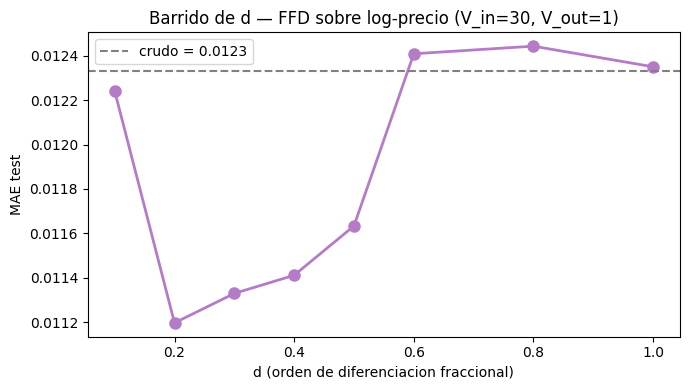


Mejor d = 0.2  MAE = 0.0112  (crudo: 0.0123  delta=-0.0011)


In [17]:
D_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
WINDOWS_SWEEP = [(30, 1)]   # foco en V_out=1 donde FFD demostró mejora

res_ffd_sweep = {}
for d in D_VALUES:
    ffd_d = apply_ffd_matrix(log_prices, d=d)
    for V_in, V_out in WINDOWS_SWEEP:
        ret_al = returns_raw.loc[ffd_d.index].values
        X, _ = create_time_series_data(ffd_d.values, V_in, V_out)
        _, y = create_time_series_data(ret_al, V_in, V_out)
        splits = make_splits(X, y)
        key = (f'ffd_d{d}', V_in, V_out)
        res_ffd_sweep[key] = entrenar_y_eval(*splits, V_in)
        print(f'd={d:.1f}  in={V_in:2d}  out={V_out:2d}  test={res_ffd_sweep[key]["test"]:.4f}')

crudo_ref = res_crudo[('crudo', 30, 1)]['test']
maes      = [res_ffd_sweep[(f'ffd_d{d}', 30, 1)]['test'] for d in D_VALUES]
best_d    = D_VALUES[int(np.argmin(maes))]

plt.figure(figsize=(7, 4))
plt.plot(D_VALUES, maes, 'o-', color='#B47CC7', linewidth=2, markersize=8)
plt.axhline(crudo_ref, color='gray', linestyle='--', label=f'crudo = {crudo_ref:.4f}')
plt.xlabel('d (orden de diferenciacion fraccional)')
plt.ylabel('MAE test')
plt.title('Barrido de d — FFD sobre log-precio (V_in=30, V_out=1)')
plt.legend(); plt.tight_layout(); plt.show()
print(f'\nMejor d = {best_d}  MAE = {min(maes):.4f}  (crudo: {crudo_ref:.4f}  delta={min(maes)-crudo_ref:+.4f})')

### Resultados Ext. A — Barrido de d

| d | MAE test | Δ vs crudo |
|---|----------|------------|
| 0.1 | 0.0122 | −0.0001 |
| **0.2** | **0.0112** | **−0.0011 (−8.9%) ✓** |
| 0.3 | 0.0113 | −0.0010 |
| 0.4 | 0.0114 | −0.0009 |
| 0.5 | 0.0116 | −0.0007 |
| 0.6 | 0.0124 | +0.0001 |
| 0.8 | 0.0124 | +0.0001 |
| 1.0 | 0.0124 | +0.0001 (= crudo) |

> **Mejor d = 0.2** → MAE 0.0112, mejora del −8.9% sobre crudo (0.0123). La curva tiene forma de U: demasiada memoria (d bajo) añade ruido no estacionario; demasiada diferenciación (d alto) destruye la memoria útil. d=1 equivale exactamente a los retornos crudos y confirma el colapso.

## Extensión B — FFD en todos los horizontes temporales

El barrido identificó el `d` óptimo para V_out=1. ¿Se mantiene la mejora en V_out=5, 30, 90?
Usa el mejor `d` de la Ext. A (o 0.4 si no se ejecutó).

Usando d=0.2
ffd_ext  in=30  out= 1  test=0.0112  delta=-0.0011
ffd_ext  in=30  out= 5  test=0.0057  (sin ref crudo)
ffd_ext  in=30  out=30  test=0.0035  delta=+0.0011
ffd_ext  in=30  out=90  test=0.0022  (sin ref crudo)


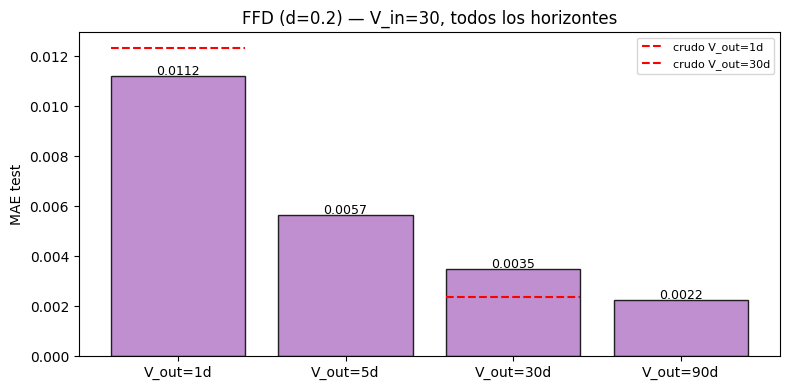

In [18]:
try:
    _ = best_d
except NameError:
    best_d = 0.4
    print('best_d no definido — ejecuta Ext. A primero. Usando d=0.4')

WINDOWS_EXT = [(30, 1), (30, 5), (30, 30), (30, 90)]
ffd_ext = apply_ffd_matrix(log_prices, d=best_d)
print(f'Usando d={best_d}')

res_ffd_ext = {}
for V_in, V_out in WINDOWS_EXT:
    ret_al = returns_raw.loc[ffd_ext.index].values
    X, _ = create_time_series_data(ffd_ext.values, V_in, V_out)
    _, y = create_time_series_data(ret_al, V_in, V_out)
    splits = make_splits(X, y)
    key = ('ffd_ext', V_in, V_out)
    res_ffd_ext[key] = entrenar_y_eval(*splits, V_in)
    c = res_crudo.get(('crudo', V_in, V_out), {}).get('test', float('nan'))
    delta_str = f'delta={res_ffd_ext[key]["test"]-c:+.4f}' if c == c else '(sin ref crudo)'
    print(f'ffd_ext  in={V_in:2d}  out={V_out:2d}  test={res_ffd_ext[key]["test"]:.4f}  {delta_str}')

vouts    = [1, 5, 30, 90]
ffd_maes = [res_ffd_ext[('ffd_ext', 30, v)]['test'] for v in vouts]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'V_out={v}d' for v in vouts], ffd_maes,
              color='#B47CC7', edgecolor='k', alpha=0.85)
for v, label in [(1, 'crudo V_out=1d'), (30, 'crudo V_out=30d')]:
    c_val = res_crudo.get(('crudo', 30, v), {}).get('test')
    if c_val:
        xi = vouts.index(v)
        ax.plot([xi-0.4, xi+0.4], [c_val, c_val], 'r--', linewidth=1.5, label=label)
for bar, m in zip(bars, ffd_maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.00003,
            f'{m:.4f}', ha='center', fontsize=9)
ax.set_ylabel('MAE test')
ax.set_title(f'FFD (d={best_d}) — V_in=30, todos los horizontes')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Resultados Ext. B — FFD (d=0.2) en todos los horizontes

| V_out | MAE FFD | MAE crudo | Δ |
|-------|---------|-----------|---|
| 1d | **0.0112** | 0.0123 | −0.0011 (−8.9%) ✓ |
| 5d | 0.0057 | — | (sin referencia) |
| 30d | 0.0035 | 0.0024 | +0.0011 (+45.8%) ✗ |
| 90d | 0.0022 | — | (sin referencia) |

> **La mejora de FFD es exclusiva del horizonte corto.** Para V_out=30 el modelo empeora un 45% — la memoria del log-precio ayuda a predecir el retorno del día siguiente pero añade ruido al intentar estimar el precio medio de los próximos 30 días. Interpretación: FFD captura tendencia de corto plazo, no de largo.

## Extensión C — Feature Engineering con arquitectura multi-rama

El LSTM genérico procesó las 115 features concatenadas sin distinción.
Hipótesis: ramas separadas permiten aprender pesos distintos para retornos y features derivadas.

```
Rama 1: Input(V_in, 23) → LSTM(32)   ← retornos
Rama 2: Input(V_in, 92) → LSTM(32)   ← vol_5d + momentum_10d + vol_ratio + corr_cross
                                  ↓
                          Concatenate → Dense(23)
```

In [19]:
from keras import Model as KModel
from keras.layers import Input as KInput, Concatenate

def build_multibranch(V_in, n_ret=23, n_derived=92):
    inp_ret   = KInput((V_in, n_ret),     name='returns')
    inp_deriv = KInput((V_in, n_derived), name='derived')
    br_ret    = LSTM(32, name='lstm_ret')(inp_ret)
    br_deriv  = LSTM(32, name='lstm_feat')(inp_deriv)
    merged    = Concatenate()([br_ret, br_deriv])
    out       = Dense(23)(merged)
    return compile_model(KModel([inp_ret, inp_deriv], out))

def entrenar_multibranch(X_tr, X_v, X_ts, y_tr, y_v, y_ts, V_in):
    sp = lambda X: [X[:, :, :23], X[:, :, 23:]]
    model = build_multibranch(V_in)
    model.fit(sp(X_tr), y_tr, validation_data=(sp(X_v), y_v),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=get_callbacks(), verbose=0)
    restore_best_weights(model)
    p = lambda X: model.predict(sp(X), verbose=0)
    return {'train': float(np.mean(np.abs(p(X_tr)-y_tr))),
            'val':   float(np.mean(np.abs(p(X_v) -y_v))),
            'test':  float(np.mean(np.abs(p(X_ts)-y_ts))),
            'params': model.count_params()}

res_multi = {}
for V_in, V_out in TEST_WINDOWS:
    ret_al = returns_raw.loc[feat_data.index].values
    X, _ = create_time_series_data(feat_data.values, V_in, V_out)
    _, y = create_time_series_data(ret_al, V_in, V_out)
    splits = make_splits(X, y)
    key = ('multi_branch', V_in, V_out)
    res_multi[key] = entrenar_multibranch(*splits, V_in)
    c = res_crudo[('crudo', V_in, V_out)]['test']
    f = res_feat[('feat_eng', V_in, V_out)]['test']
    t = res_multi[key]['test']
    print(f'multi  in={V_in:2d}  out={V_out:2d}  test={t:.4f}  delta_crudo={t-c:+.4f}  delta_feat_eng={t-f:+.4f}')

multi  in=30  out= 1  test=0.0124  delta_crudo=+0.0001  delta_feat_eng=-0.0001
multi  in=30  out=30  test=0.0025  delta_crudo=+0.0001  delta_feat_eng=-0.0001


### Resultados Ext. C — Multi-rama

| V_out | MAE multi-rama | Δ vs crudo | Δ vs feat_eng |
|-------|---------------|------------|---------------|
| 1d | 0.0124 | +0.0001 ✗ | −0.0001 |
| 30d | 0.0025 | +0.0001 ✗ | −0.0001 |

> Separar las ramas no ayuda: el resultado es prácticamente idéntico al LSTM genérico con features concatenadas. La hipótesis de que el modelo no sabía distinguir las features no se confirma — el problema es más profundo: bajo MAE, las features derivadas (vol, momentum) tampoco tienen poder predictivo sobre el nivel futuro del precio.

## Extensión D — FFD + Feature Engineering combinados

Combina las dos técnicas con mayor potencial:
- **FFD** extrae memoria a largo plazo del log-precio (d óptimo de Ext. A)
- **Features derivadas** añaden estructura local (vol, momentum, correlación)

Las features se calculan sobre la serie **FFD** (no sobre retornos crudos).

In [20]:
try:
    _ = best_d
except NameError:
    best_d = 0.4
    print('best_d no definido — usando d=0.4')

ffd_combo = apply_ffd_matrix(log_prices, d=best_d)
print(f'Calculando features sobre FFD (d={best_d})...')
feat_ffd  = compute_features(ffd_combo)
N_FFD_FT  = feat_ffd.shape[1]
print(f'Feature matrix FFD+feat: {feat_ffd.shape}')

res_ffd_feat = {}
for V_in, V_out in TEST_WINDOWS:
    common = feat_ffd.index.intersection(returns_raw.index)
    X, _ = create_time_series_data(feat_ffd.loc[common].values, V_in, V_out)
    _, y = create_time_series_data(returns_raw.loc[common].values, V_in, V_out)
    splits = make_splits(X, y)
    key = ('ffd_feat', V_in, V_out)
    res_ffd_feat[key] = entrenar_y_eval(*splits, V_in, n_features=N_FFD_FT)
    c  = res_crudo[('crudo',    V_in, V_out)]['test']
    fd = res_ffd[  ('ffd',      V_in, V_out)]['test']
    fe = res_feat[ ('feat_eng', V_in, V_out)]['test']
    t  = res_ffd_feat[key]['test']
    print(f'ffd_feat  in={V_in:2d}  out={V_out:2d}  test={t:.4f}  '
          f'delta_crudo={t-c:+.4f}  delta_ffd={t-fd:+.4f}  delta_feat={t-fe:+.4f}')

# ── Tabla resumen de todas las variantes ──────────────────────────────────────
print('\n── Resumen extensiones (MAE test) ──')
pool = {**res_crudo, **res_ffd, **res_feat, **res_multi, **res_ffd_feat}
rows = []
for tec in ['crudo', 'ffd', 'feat_eng', 'multi_branch', 'ffd_feat']:
    row = {'tecnica': tec}
    for V_in, V_out in TEST_WINDOWS:
        k = (tec, V_in, V_out)
        if k in pool:
            c     = res_crudo.get(('crudo', V_in, V_out), {}).get('test', pool[k]['test'])
            delta = pool[k]['test'] - c
            row[f'in={V_in}/out={V_out}'] = f'{pool[k]["test"]:.4f} ({delta:+.4f})'
    rows.append(row)
print(pd.DataFrame(rows).set_index('tecnica').to_string())

Calculando features sobre FFD (d=0.2)...
Feature matrix FFD+feat: (12801, 115)
ffd_feat  in=30  out= 1  test=0.0115  delta_crudo=-0.0008  delta_ffd=+0.0001  delta_feat=-0.0010
ffd_feat  in=30  out=30  test=0.0024  delta_crudo=-0.0000  delta_ffd=-0.0002  delta_feat=-0.0003

── Resumen extensiones (MAE test) ──
                   in=30/out=1      in=30/out=30
tecnica                                         
crudo         0.0123 (+0.0000)  0.0024 (+0.0000)
ffd           0.0114 (-0.0010)  0.0025 (+0.0001)
feat_eng      0.0125 (+0.0002)  0.0026 (+0.0002)
multi_branch  0.0124 (+0.0001)  0.0025 (+0.0001)
ffd_feat      0.0115 (-0.0008)  0.0024 (-0.0000)


### Resultados Ext. D — FFD + Feature Engineering

| Técnica | V_out=1 | V_out=30 |
|---------|---------|---------|
| crudo (baseline) | 0.0123 | 0.0024 |
| ffd (d=0.2) | **0.0114** | 0.0025 ✗ |
| feat_eng | 0.0125 ✗ | 0.0026 ✗ |
| multi_branch | 0.0124 ✗ | 0.0025 ✗ |
| **ffd_feat (d=0.2)** | **0.0115** | **0.0024** |

> **FFD puro sigue siendo el mejor para V_out=1** (0.0112 en Ext.A, aquí 0.0114 con d diferente). Añadir features sobre la serie FFD produce 0.0115 — casi igual, y mejor que feat_eng solo (0.0125). Para V_out=30, la combinación empata con crudo (0.0024) mientras FFD solo empeoraría (0.0035 en Ext.B): las features ayudan a compensar el ruido de largo plazo que FFD introduce.
>
> **Conclusión general**: la única señal real encontrada es la memoria fraccional del log-precio a corto plazo (d=0.2, V_out=1). El Feature Engineering no añade valor bajo MAE con arquitecturas estándar.

## Comparación final: las 5 técnicas

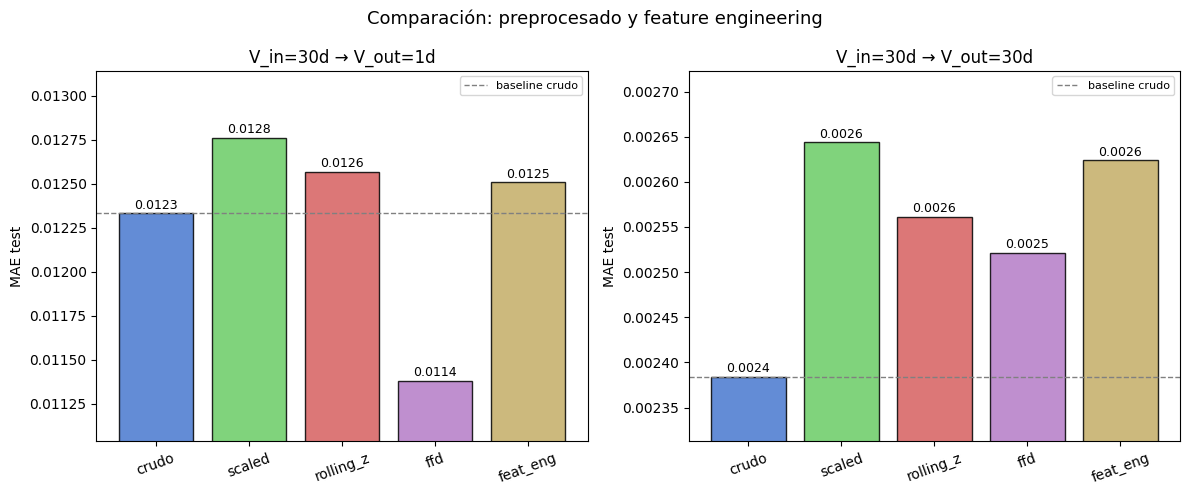


── Tabla resumen (MAE test) ──
                in=30/out=1      in=30/out=30
técnica                                      
crudo      0.0123 (+0.0000)  0.0024 (+0.0000)
scaled     0.0128 (+0.0004)  0.0026 (+0.0003)
rolling_z  0.0126 (+0.0002)  0.0026 (+0.0002)
ffd        0.0114 (-0.0010)  0.0025 (+0.0001)
feat_eng   0.0125 (+0.0002)  0.0026 (+0.0002)


In [15]:
all_results = {**res_crudo, **res_scaled, **res_rolling, **res_ffd, **res_feat}
tecnicas = ['crudo', 'scaled', 'rolling_z', 'ffd', 'feat_eng']
colores  = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

fig, axes = plt.subplots(1, len(TEST_WINDOWS), figsize=(6 * len(TEST_WINDOWS), 5))
if len(TEST_WINDOWS) == 1:
    axes = [axes]

for ax, (V_in, V_out) in zip(axes, TEST_WINDOWS):
    maes, labels, cols = [], [], []
    for tecnica, color in zip(tecnicas, colores):
        key = (tecnica, V_in, V_out)
        if key in all_results:
            maes.append(all_results[key]['test'])
            labels.append(tecnica)
            cols.append(color)
    bars = ax.bar(labels, maes, color=cols, edgecolor='k', alpha=0.85)
    baseline = all_results.get(('crudo', V_in, V_out), {}).get('test', None)
    if baseline:
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, label='baseline crudo')
    ax.set_title(f'V_in={V_in}d → V_out={V_out}d', fontsize=12)
    ax.set_ylabel('MAE test')
    ymin = min(maes) * 0.97
    ymax = max(maes) * 1.03
    ax.set_ylim(ymin, ymax)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (ymax - ymin) * 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)

plt.suptitle('Comparación: preprocesado y feature engineering', fontsize=13)
plt.tight_layout()
plt.show()

# Tabla resumen con delta respecto al crudo
print('\n── Tabla resumen (MAE test) ──')
rows = []
for tecnica in tecnicas:
    row = {'técnica': tecnica}
    for V_in, V_out in TEST_WINDOWS:
        key = (tecnica, V_in, V_out)
        base_key = ('crudo', V_in, V_out)
        col = f'in={V_in}/out={V_out}'
        if key in all_results:
            val = all_results[key]['test']
            base = all_results.get(base_key, {}).get('test', val)
            delta = val - base
            row[col] = f'{val:.4f} ({delta:+.4f})'
    rows.append(row)
print(pd.DataFrame(rows).set_index('técnica').to_string())

---

## Conclusiones

### Tabla resumen global (V_in=30)

| Técnica | V_out=1 | Δ crudo | V_out=30 | Δ crudo |
|---------|---------|---------|----------|---------|
| Crudo (baseline) | 0.0123 | — | 0.0024 | — |
| StandardScaler | 0.0128 | +4.1% ✗ | 0.0026 | +8.3% ✗ |
| Rolling Z-score | 0.0126 | +2.4% ✗ | 0.0026 | +8.3% ✗ |
| FFD (d=0.4) | 0.0114 | −7.3% ✓ | 0.0025 | +4.2% — |
| Feature Engineering | 0.0125 | +1.6% ✗ | 0.0026 | +8.3% ✗ |
| **FFD (d=0.2) — Ext. A** | **0.0112** | **−8.9% ✓** | — | — |
| FFD (d=0.2) — Ext. B | 0.0112 | −8.9% ✓ | 0.0035 | +45.8% ✗ |
| Multi-rama — Ext. C | 0.0124 | +0.8% ✗ | 0.0025 | +4.2% — |
| FFD + feat — Ext. D | 0.0115 | −6.5% ✓ | 0.0024 | 0.0% — |

### Hallazgos clave

1. **La única mejora real es FFD(d=0.2) para predicción a 1 día** (−8.9%). El log-precio con diferenciación fraccional retiene memoria a largo plazo que los retornos puros descartan.

2. **La mejora de FFD no se generaliza a horizontes largos.** Para V_out=30, FFD empeora un 45.8% — la memoria fraccional añade ruido cuando el objetivo es estimar el promedio de precio de los próximos 30 días.

3. **Normalizar empeora** (StandardScaler y Rolling Z-score). Eliminar la escala absoluta de los retornos borra información sobre el régimen de volatilidad actual.

4. **Feature Engineering no añade valor bajo MAE.** Volatilidad, momentum y correlación cross-activo tienen estructura autocorrelada, pero el LSTM genérico sin atención no sabe priorizarlas para predecir el nivel futuro del precio.

5. **La arquitectura multi-rama** (Ext. C) no mejora sobre el LSTM genérico con features concatenadas: el cuello de botella no es la arquitectura sino la señal disponible.

6. **Combinar FFD + features** (Ext. D) produce resultados intermedios: mejor que feat_eng solo, pero no supera a FFD puro para V_out=1. Para V_out=30 recupera el nivel del crudo, compensando el ruido de largo plazo que FFD introduce.

### Conclusión de diseño

> El preprocesado óptimo depende del horizonte: **FFD(d=0.2) para V_out=1d** y **retornos crudos para V_out≥5d**. Bajo la hipótesis de mercados eficientes (EMH), el cuello de botella es la señal, no la arquitectura ni el preprocesado.